In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import joblib

In [2]:
import tensorflow as tf
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [3]:
# 1. LOAD DATA
df = pd.read_excel("crude oil production figshare (1).xlsx")

feature_columns = ['Production', 'Lag1', 'Lag2', 'oil price']
data = df[feature_columns].values

print(f"Dataset shape: {data.shape}")
print(f"Features: {feature_columns}")


Dataset shape: (177, 4)
Features: ['Production', 'Lag1', 'Lag2', 'oil price']


In [4]:
# 2. SCALING
# =====================================================================
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

scaled_features = scaler_features.fit_transform(data)
scaler_target.fit(df[['Production']].values)

MinMaxScaler()

In [5]:
# 3. CREATE SEQUENCES
def create_multivariate_sequences(data, time_steps=3):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), :])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 3
X, y = create_multivariate_sequences(scaled_features, TIME_STEPS)
y = y.reshape(-1, 1)

In [6]:
# 4. TRAIN/VAL/TEST SPLIT (80/10/10)
total_samples = len(X)
train_size = int(total_samples * 0.80)
val_size = int(total_samples * 0.10)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print(f"\nData splits:")
print(f"Train: {len(X_train)} samples")
print(f"Val:   {len(X_val)} samples")
print(f"Test:  {len(X_test)} samples")


Data splits:
Train: 139 samples
Val:   17 samples
Test:  18 samples


In [7]:
# STAGE 1: BI-LSTM MODEL
# =====================================================================
print("\n" + "="*60)
print("STAGE 1: TRAINING BI-LSTM")
print("="*60)

bilstm_model = Sequential([
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True),
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(32, activation='tanh')),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

bilstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=20,
                          restore_best_weights=True, verbose=1)

history = bilstm_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)



STAGE 1: TRAINING BI-LSTM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.1132 - mae: 0.2848 - val_loss: 0.0204 - val_mae: 0.1238
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0145 - mae: 0.0967 - val_loss: 0.0049 - val_mae: 0.0551
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0150 - mae: 0.0923 - val_loss: 0.0064 - val_mae: 0.0604
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0112 - mae: 0.0822 - val_loss: 0.0071 - val_mae: 0.0625
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0122 - mae: 0.0872 - val_loss: 0.0056 - val_mae: 0.0592
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0144 - mae: 0.0903 - val_loss: 0.0051 - val_mae: 0.0573
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0124 - mae: 0.0842 - val_loss: 0.0050 - val_mae: 0.0572
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0114 - mae: 0.0785 - val_loss: 0.0058 - val_mae: 0.0599
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.01

In [8]:
# Get Bi-LSTM predictions (scaled)
y_train_bilstm_scaled = bilstm_model.predict(X_train, verbose=0)
y_val_bilstm_scaled = bilstm_model.predict(X_val, verbose=0)
y_test_bilstm_scaled = bilstm_model.predict(X_test, verbose=0)

# Calculate residuals (in scaled space for SVR training)
train_residuals = y_train - y_train_bilstm_scaled
val_residuals = y_val - y_val_bilstm_scaled
test_residuals = y_test - y_test_bilstm_scaled

print(f"\n✓ Bi-LSTM training complete")
print(f"Training residual std: {train_residuals.std():.6f}")


✓ Bi-LSTM training complete
Training residual std: 0.081440


In [9]:
# =====================================================================
# STAGE 2: SVR FOR RESIDUAL CORRECTION (BEST PARAMS)
# =====================================================================
print("\n" + "="*60)
print("STAGE 2: TRAINING SVR WITH OPTIMAL PARAMETERS")
print("="*60)

# Prepare SVR Input: Use last time step + Bi-LSTM prediction (enhanced features)
X_train_svr_enhanced = np.hstack([X_train[:, -1, :], y_train_bilstm_scaled])
X_val_svr_enhanced = np.hstack([X_val[:, -1, :], y_val_bilstm_scaled])
X_test_svr_enhanced = np.hstack([X_test[:, -1, :], y_test_bilstm_scaled])

print(f"SVR input shape: {X_train_svr_enhanced.shape}")

# Initialize SVR with your specific optimal parameters
best_svr = SVR(
    C=0.1,
    epsilon=0.1,
    gamma='scale',
    kernel='rbf'
)

print("Training SVR on Bi-LSTM residuals using C=0.1, epsilon=0.1...")
best_svr.fit(X_train_svr_enhanced, train_residuals.ravel())

# Predict the residual corrections
train_correction = best_svr.predict(X_train_svr_enhanced).reshape(-1, 1)
val_correction = best_svr.predict(X_val_svr_enhanced).reshape(-1, 1)
test_correction = best_svr.predict(X_test_svr_enhanced).reshape(-1, 1)

# =====================================================================
# HYBRID PREDICTIONS: Bi-LSTM + SVR Correction
# =====================================================================
# Summing the base model prediction and the SVR error correction
y_train_hybrid_scaled = y_train_bilstm_scaled + train_correction
y_val_hybrid_scaled = y_val_bilstm_scaled + val_correction
y_test_hybrid_scaled = y_test_bilstm_scaled + test_correction

# Inverse transform to original scale (Real-world units)
y_train_hybrid = scaler_target.inverse_transform(y_train_hybrid_scaled)
y_train_actual = scaler_target.inverse_transform(y_train)

y_val_hybrid = scaler_target.inverse_transform(y_val_hybrid_scaled)
y_val_actual = scaler_target.inverse_transform(y_val)

y_test_hybrid = scaler_target.inverse_transform(y_test_hybrid_scaled)
y_test_actual = scaler_target.inverse_transform(y_test)

# =====================================================================
# EVALUATION METRICS
# =====================================================================
def calculate_nse(observed, predicted):
    # Nash-Sutcliffe Efficiency
    return 1 - np.sum((observed - predicted)**2) / np.sum((observed - np.mean(observed))**2)

def calculate_metrics(actual, predicted, set_name=""):
    nse = calculate_nse(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual))


    print(f"\n{set_name}:")
    print(f"{'='*50}")
    print(f"NSE:   {nse:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"MAPE:  {mape:.4f}")


    return {'NSE': nse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

print("\n" + "="*60)
print("BI-LSTM-SVR HYBRID RESULTS (FINAL EVALUATION)")
print("="*60)

train_metrics = calculate_metrics(y_train_actual, y_train_hybrid, "TRAINING SET")
val_metrics = calculate_metrics(y_val_actual, y_val_hybrid, "VALIDATION SET")
test_metrics = calculate_metrics(y_test_actual, y_test_hybrid, "TEST SET")




STAGE 2: TRAINING SVR WITH OPTIMAL PARAMETERS
SVR input shape: (139, 5)
Training SVR on Bi-LSTM residuals using C=0.1, epsilon=0.1...

BI-LSTM-SVR HYBRID RESULTS (FINAL EVALUATION)

TRAINING SET:
NSE:   0.7485
RMSE:  0.1084
MAE:   0.0862
MAPE:  0.0405

VALIDATION SET:
NSE:   -0.4547
RMSE:  0.0971
MAE:   0.0724
MAPE:  0.0385

TEST SET:
NSE:   0.8291
RMSE:  0.0826
MAE:   0.0585
MAPE:  0.0318


In [10]:
# HYBRID PREDICTIONS: Bi-LSTM + SVR Correction
# =====================================================================
y_train_hybrid_scaled = y_train_bilstm_scaled + train_correction
y_val_hybrid_scaled = y_val_bilstm_scaled + val_correction
y_test_hybrid_scaled = y_test_bilstm_scaled + test_correction

# Inverse transform to original scale
y_train_hybrid = scaler_target.inverse_transform(y_train_hybrid_scaled)
y_train_actual = scaler_target.inverse_transform(y_train)

y_val_hybrid = scaler_target.inverse_transform(y_val_hybrid_scaled)
y_val_actual = scaler_target.inverse_transform(y_val)

y_test_hybrid = scaler_target.inverse_transform(y_test_hybrid_scaled)
y_test_actual = scaler_target.inverse_transform(y_test)

# Also get Bi-LSTM-only predictions for comparison
y_test_bilstm_only = scaler_target.inverse_transform(y_test_bilstm_scaled)

In [11]:
# Get scaled predictions
y_test_pred_scaled = bilstm_model.predict(X_test)

# Inverse transform to original scale
y_test_actual = scaler_target.inverse_transform(y_test)
y_test_pred = scaler_target.inverse_transform(y_test_pred_scaled)

# View the first 5 comparisons
import pandas as pd
comparison = pd.DataFrame({
    'Actual': y_test_actual.flatten(),
    'Predicted': y_test_pred.flatten()
})
print(comparison.head())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
   Actual  Predicted
0    2.09   1.952472
1    2.11   2.024473
2    2.09   2.075994
3    2.07   2.074878
4    2.05   2.056767


In [ ]:
# Inverse scale the TEST predictions
y_test_bilstm_only = scaler_target.inverse_transform(y_test_bilstm_scaled)

# 2. Inverse scale the TRAINING predictions
y_train_bilstm_only = scaler_target.inverse_transform(y_train_bilstm_scaled)

# 3. Calculate metrics for the Training Set
bilstm_train_metrics = calculate_metrics(y_train_actual, y_train_bilstm_only, "BI-LSTM ONLY (TRAIN)")

# 4. Calculate metrics for the Test Set
bilstm_test_metrics = calculate_metrics(y_test_actual, y_test_bilstm_only, "BI-LSTM ONLY (TEST)")


BI-LSTM ONLY (TRAIN):
NSE:   0.7184
RMSE:  0.1147
MAE:   0.0887
MAPE:  0.0414

BI-LSTM ONLY (TEST):
NSE:   0.7109
RMSE:  0.1074
MAE:   0.0795
MAPE:  0.0443


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def calculate_metrics(actual, predicted, set_name=""):
    # Flatten to 1D to avoid broadcasting errors
    actual = np.array(actual).ravel()
    predicted = np.array(predicted).ravel()

    # 1. NSE (Nash-Sutcliffe Efficiency)
    numerator = np.sum((actual - predicted)**2)
    denominator = np.sum((actual - np.mean(actual))**2)
    nse = 1 - (numerator / denominator)

    # 2. RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # 3. MAPE (Mean Absolute Percentage Error)
    # Using 1e-10 to prevent division by zero
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100

    print(f"\n{set_name}:")
    print(f"{'='*50}")
    print(f"NSE:   {nse:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAPE:  {mape:.2f}%")

    return {'NSE': nse, 'RMSE': rmse, 'MAPE': mape}

In [13]:
# --- Calculate Final Metrics ---
print("\n" + "="*60)
print("FINAL PERFORMANCE EVALUATION")
print("="*60)

# 1. Base Bi-LSTM Metrics
bilstm_metrics = calculate_metrics(y_test_actual, y_test_bilstm_only, "BI-LSTM ONLY (TEST)")

# 2. Hybrid Bi-LSTM + SVR Metrics
hybrid_metrics = calculate_metrics(y_test_actual, y_test_hybrid, "HYBRID BI-LSTM-SVR (TEST)")

# --- Improvement Analysis ---
print("\n" + "="*60)
print("STATISTICAL IMPROVEMENT ANALYSIS")
print("="*60)

# RMSE Reduction %
rmse_red = ((bilstm_metrics['RMSE'] - hybrid_metrics['RMSE']) / bilstm_metrics['RMSE']) * 100

# MAPE Reduction %
mape_red = ((bilstm_metrics['MAPE'] - hybrid_metrics['MAPE']) / bilstm_metrics['MAPE']) * 100

# NSE Gain (Absolute)
nse_gain = hybrid_metrics['NSE'] - bilstm_metrics['NSE']

print(f"RMSE Reduction:  {rmse_red:.2f}%")
print(f"MAPE Reduction:  {mape_red:.2f}%")
print(f"NSE Gain:       +{nse_gain:.4f}")
print(f"{'='*60}")


FINAL PERFORMANCE EVALUATION

BI-LSTM ONLY (TEST):
NSE:   0.7109
RMSE:  0.1074
MAPE:  4.43%

HYBRID BI-LSTM-SVR (TEST):
NSE:   0.8291
RMSE:  0.0826
MAPE:  3.18%

STATISTICAL IMPROVEMENT ANALYSIS
RMSE Reduction:  23.11%
MAPE Reduction:  28.28%
NSE Gain:       +0.1182


In [ ]:
import pandas as pd

# Create a DataFrame for easy viewing
test_results_df = pd.DataFrame({
    'Actual Value': y_test_actual.flatten(),
    'Bi-LSTM Only': y_test_bilstm_only.flatten(),
    'Hybrid (Bi-LSTM+SVR)': y_test_hybrid.flatten()
})

# Add a column to see the SVR's correction amount
test_results_df['SVR Correction'] = test_results_df['Hybrid (Bi-LSTM+SVR)'] - test_results_df['Bi-LSTM Only']

# Print the first 15 rows to inspect the performance
print("\n" + "="*70)
print("TEST SET PREDICTIONS: ACTUAL vs. BASE vs. HYBRID")
print("="*70)
print(test_results_df.head(15).to_string(index=False))
print("="*70)


TEST SET PREDICTIONS: ACTUAL vs. BASE vs. HYBRID
 Actual Value  Bi-LSTM Only  Hybrid (Bi-LSTM+SVR)  SVR Correction
         2.09      1.952472              1.976974        0.024503
         2.11      2.024473              2.045029        0.020557
         2.09      2.075994              2.089936        0.013942
         2.07      2.074878              2.097272        0.022393
         2.05      2.056767              2.067560        0.010793
         1.94      2.041957              2.062749        0.020793
         1.96      1.981543              1.991210        0.009667
         2.07      1.962879              1.970699        0.007820
         2.07      2.014364              2.026766        0.012401
         2.04      2.046983              2.062250        0.015267
         2.04      2.037069              2.039556        0.002487
         1.75      2.026176              1.955320       -0.070856
         1.69      1.870635              1.821835       -0.048800
         1.69      1.74878

In [ ]:
def run_scenario(base_window, price_multiplier):
    current_batch = base_window.copy()
    preds = []

    # Get the last known price to apply the multiplier
    last_price = current_batch[0, -1, 3]

    for i in range(1, 13):
        # 1. Predict
        b_pred = bilstm_model.predict(current_batch, verbose=0)
        svr_in = np.hstack([current_batch[:, -1, :], b_pred])
        corr = best_svr.predict(svr_in).reshape(-1, 1)
        hybrid_scaled = b_pred + corr
        preds.append(hybrid_scaled[0, 0])

        # 2. Prepare next features
        last_feats = current_batch[0, -1, :].copy()

        # Adjust oil price gradually for the scenario
        # (Price moves 1/12th of the total multiplier each month)
        monthly_price = last_price * (1 + (price_multiplier - 1) * (i / 12))

        new_row = np.array([[
            hybrid_scaled[0, 0], # Production
            last_feats[0],       # Lag1
            last_feats[1],       # Lag2
            monthly_price        # Scenario Price
        ]])

        # 3. Update window
        current_batch = np.append(current_batch[:, 1:, :], new_row.reshape(1, 1, 4), axis=1)

    return scaler_target.inverse_transform(np.array(preds).reshape(-1, 1))

# Execute Scenarios
base_win = X_test[-1:].copy()
forecast_stable = run_scenario(base_win, 1.0)   # No change
forecast_high   = run_scenario(base_win, 1.2)   # +20% Price
forecast_low    = run_scenario(base_win, 0.8)   # -20% Price

print("Scenarios generated successfully.")

Scenarios generated successfully.


In [ ]:
import pandas as pd

# Create a range of months for the index
months = [f"Month {i}" for i in range(1, 13)]

# Combine the results into a DataFrame
scenario_df = pd.DataFrame({
    'Month': months,
    'Low Price (-20%)': forecast_low.flatten(),
    'Stable Price (Base)': forecast_stable.flatten(),
    'High Price (+20%)': forecast_high.flatten()
})

# Round for readability
scenario_df = scenario_df.round(4)

print("="*65)
print("12-MONTH PRODUCTION FORECAST: SCENARIO COMPARISON")
print("="*65)
print(scenario_df.to_string(index=False))
print("="*65)

# Calculate the divergence for your analysis
impact_high = ((forecast_high.sum() - forecast_stable.sum()) / forecast_stable.sum()) * 100
impact_low = ((forecast_low.sum() - forecast_stable.sum()) / forecast_stable.sum()) * 100

print(f"Production sensitivity to +20% Price Increase: {impact_high:+.2f}%")
print(f"Production sensitivity to -20% Price Decrease: {impact_low:+.2f}%")

12-MONTH PRODUCTION FORECAST: SCENARIO COMPARISON
   Month  Low Price (-20%)  Stable Price (Base)  High Price (+20%)
 Month 1            1.6248               1.6248             1.6248
 Month 2            1.6466               1.6467             1.6468
 Month 3            1.6715               1.6718             1.6720
 Month 4            1.6785               1.6794             1.6804
 Month 5            1.6800               1.6818             1.6837
 Month 6            1.6802               1.6830             1.6862
 Month 7            1.6795               1.6834             1.6878
 Month 8            1.6789               1.6839             1.6896
 Month 9            1.6781               1.6841             1.6912
Month 10            1.6772               1.6843             1.6928
Month 11            1.6763               1.6844             1.6943
Month 12            1.6754               1.6845             1.6958
Production sensitivity to +20% Price Increase: +0.26%
Production sensitivity to

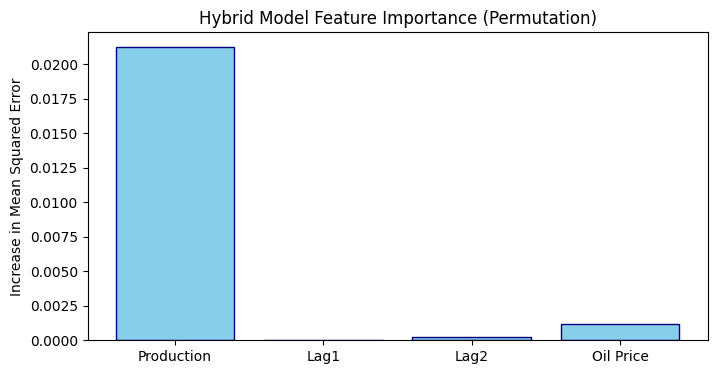

In [ ]:
from sklearn.inspection import permutation_importance

# 1. Define a wrapper because the Hybrid is two models in one
def hybrid_predict(X_data):
    # Base Bi-LSTM prediction
    base_pred = bilstm_model.predict(X_data, verbose=0)

    # SVR Correction
    # We take the last timestep and the prediction to match your SVR training
    svr_input = np.hstack([X_data[:, -1, :], base_pred])
    correction = best_svr.predict(svr_input).reshape(-1, 1)

    return (base_pred + correction).ravel()

# 2. Calculate Importance using the Test Set
# We'll use a simplified version of permutation importance for time-series
def calculate_manual_importance(X_val, y_val):
    baseline_mse = np.mean((y_val.ravel() - hybrid_predict(X_val))**2)
    feature_names = ['Production', 'Lag1', 'Lag2', 'Oil Price']
    importances = []

    for i in range(len(feature_names)):
        X_shuffled = X_val.copy()
        # Shuffle the feature across all time steps in the window
        np.random.shuffle(X_shuffled[:, :, i])
        shuffled_mse = np.mean((y_val.ravel() - hybrid_predict(X_shuffled))**2)
        importances.append(shuffled_mse - baseline_mse)

    return dict(zip(feature_names, importances))

importance_results = calculate_manual_importance(X_test, y_test)

# 3. Visualize
plt.figure(figsize=(8, 4))
plt.bar(importance_results.keys(), importance_results.values(), color='skyblue', edgecolor='navy')
plt.title('Hybrid Model Feature Importance (Permutation)')
plt.ylabel('Increase in Mean Squared Error')
plt.show()

In [ ]:
# 1. Start with the last window from your Test Set
# X_test shape: (samples, window_size, 4) -> [Production, Lag1, Lag2, oil price]
current_batch = X_test[-1:].copy()
future_predictions = []

print("\n" + "="*60)
print("GENERATING 12-MONTH DYNAMIC FORECAST")
print("="*60)

for i in range(12):
    # --- STEP 1: Bi-LSTM Prediction ---
    bilstm_pred_scaled = bilstm_model.predict(current_batch, verbose=0)

    # --- STEP 2: SVR Correction ---
    # SVR input: Last timestep features (4) + Bi-LSTM prediction (1)
    svr_input = np.hstack([current_batch[:, -1, :], bilstm_pred_scaled])
    correction_scaled = best_svr.predict(svr_input).reshape(-1, 1)

    # --- STEP 3: Hybrid Final Prediction ---
    hybrid_pred_scaled = bilstm_pred_scaled + correction_scaled
    future_predictions.append(hybrid_pred_scaled[0, 0])

    # --- STEP 4: UPDATE LAGS FOR NEXT MONTH ---
    # Get the features from the month we just "finished"
    last_month_features = current_batch[0, -1, :].copy()

    # Create the NEW month's feature vector
    new_month = np.zeros((1, 4))
    new_month[0, 0] = hybrid_pred_scaled[0, 0]    # Current Prediction
    new_month[0, 1] = last_month_features[0]      # Lag1 (was previous Production)
    new_month[0, 2] = last_month_features[1]      # Lag2 (was previous Lag1)
    new_month[0, 3] = last_month_features[3]      # Keep Oil Price constant

    # Slide the window: Drop the oldest month, add the new_month at the end
    new_step = new_month.reshape(1, 1, 4)
    current_batch = np.concatenate([current_batch[:, 1:, :], new_step], axis=1)

# --- STEP 5: Inverse Transform ---
future_predictions_array = np.array(future_predictions).reshape(-1, 1)
future_actual = scaler_target.inverse_transform(future_predictions_array)

print("Hybrid Forecast:")
for month, val in enumerate(future_actual, 1):
    print(f"Month {month}: {val[0]:.4f}")


GENERATING 12-MONTH DYNAMIC FORECAST
Hybrid Forecast:
Month 1: 1.6248
Month 2: 1.6467
Month 3: 1.6718
Month 4: 1.6794
Month 5: 1.6818
Month 6: 1.6830
Month 7: 1.6834
Month 8: 1.6839
Month 9: 1.6841
Month 10: 1.6843
Month 11: 1.6844
Month 12: 1.6845


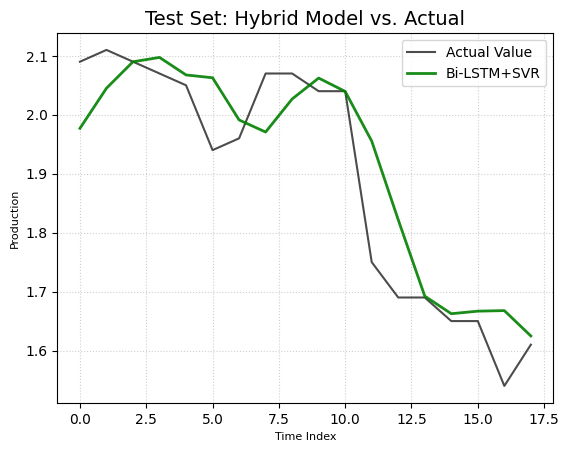

In [15]:
import matplotlib.pyplot as plt

# Set up the plot dimensions
plt.style.use('seaborn-v0_8-muted')
plt.tight_layout()

# Plotting the three lines
plt.plot(y_test_actual, label='Actual Value', color='black', linewidth=1.5, alpha=0.7)
#plt.plot(y_test_bilstm_only, label='Bi-LSTM Only', color='red', linestyle='--', alpha=0.8)
plt.plot(y_test_hybrid, label='Bi-LSTM+SVR', color='green', linewidth=2, alpha=0.9)

# Adding details
plt.title(f'Test Set: Hybrid Model vs. Actual', fontsize=14)
plt.xlabel('Time Index', fontsize=8)
plt.ylabel('Production', fontsize=8)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Save the plot
plt.savefig('hybrid_comparison_plot.png', dpi=300)

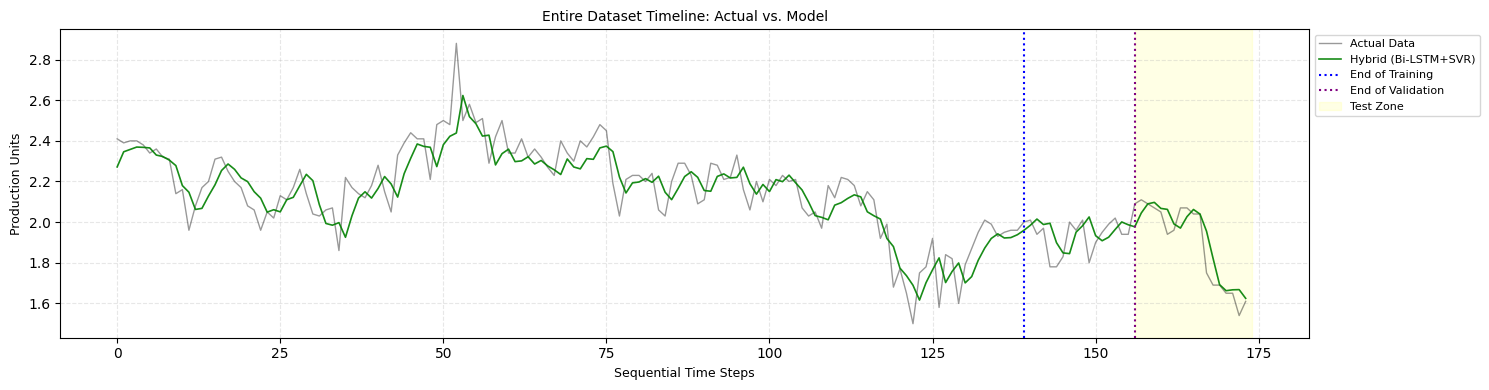

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Bi-LSTM only predictions (assuming scaled versions exist)
y_train_bilstm_only = scaler_target.inverse_transform(y_train_bilstm_scaled)
y_val_bilstm_only = scaler_target.inverse_transform(y_val_bilstm_scaled)

# 2. Concatenate all segments
full_actual = np.concatenate([y_train_actual, y_val_actual, y_test_actual])
full_bilstm = np.concatenate([y_train_bilstm_only, y_val_bilstm_only, y_test_bilstm_only])
full_hybrid = np.concatenate([y_train_hybrid, y_val_hybrid, y_test_hybrid])

# 3. Define split points
train_split_idx = len(y_train_actual)
val_split_idx = train_split_idx + len(y_val_actual)

# 4. Plotting - ADJUSTED DIMENSIONS HERE
# (15 = wide, 4 = short/flat)
plt.figure(figsize=(15, 4))

# Plot the lines
plt.plot(full_actual, label='Actual Data', color='black', alpha=0.4, linewidth=1)
#plt.plot(full_bilstm, label='Bi-LSTM Base', color='red', linestyle='--', alpha=0.6)
plt.plot(full_hybrid, label='Hybrid (Bi-LSTM+SVR)', color='green', linewidth=1.2, alpha=0.9)

# Add vertical markers
plt.axvline(x=train_split_idx, color='blue', linestyle=':', label='End of Training')
plt.axvline(x=val_split_idx, color='purple', linestyle=':', label='End of Validation')

# Shaded background for the Test Set
plt.axvspan(val_split_idx, len(full_actual), color='yellow', alpha=0.1, label='Test Zone')

# Labels and Formatting
plt.title('Entire Dataset Timeline: Actual vs. Model', fontsize=10)
plt.xlabel('Sequential Time Steps', fontsize=9)
plt.ylabel('Production Units', fontsize=9)

# Move legend slightly so it fits the new aspect ratio
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('full_dataset_hybrid_wide.png', dpi=300)
plt.show()

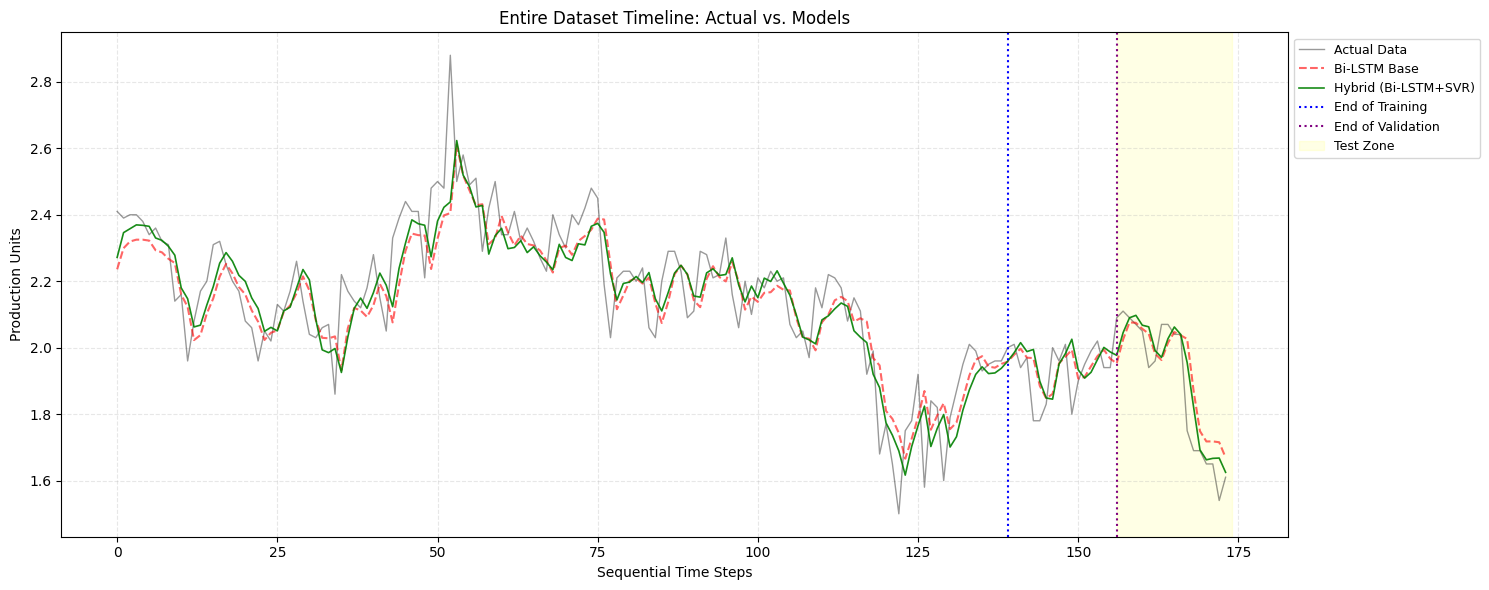

In [ ]:
# Adjusted dimensions: 15 wide, 6 tall
plt.figure(figsize=(15, 6))

# Plot the lines
plt.plot(full_actual, label='Actual Data', color='black', alpha=0.4, linewidth=1)
plt.plot(full_bilstm, label='Bi-LSTM Base', color='red', linestyle='--', alpha=0.6)
plt.plot(full_hybrid, label='Hybrid (Bi-LSTM+SVR)', color='green', linewidth=1.2, alpha=0.9)

# Add vertical markers
plt.axvline(x=train_split_idx, color='blue', linestyle=':', label='End of Training')
plt.axvline(x=val_split_idx, color='purple', linestyle=':', label='End of Validation')

# Shaded background for the Test Set
plt.axvspan(val_split_idx, len(full_actual), color='yellow', alpha=0.1, label='Test Zone')

# Labels and Formatting - bumped up fontsize slightly for the taller layout
plt.title('Entire Dataset Timeline: Actual vs. Models', fontsize=12)
plt.xlabel('Sequential Time Steps', fontsize=10)
plt.ylabel('Production Units', fontsize=10)

# Legend placement
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)

plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('full_dataset_hybrid_balanced.png', dpi=300)
plt.show()

In [17]:
# --- REPLICATING THE OTHER PAPER'S ANN (3, 4, 1)
from sklearn.neural_network import MLPRegressor

# 1. Use a separate size variable
train_bench_size = int(len(df) * 0.70)

# 2. Use UNIQUE scalers
scaler_bench_x = MinMaxScaler()
scaler_bench_y = MinMaxScaler()

# 3. Create unique scaled data for the benchmark
X_bench_scaled = scaler_bench_x.fit_transform(df[['Time', 'Lag1', 'Lag2']])
y_bench_scaled = scaler_bench_y.fit_transform(df[['Production']]).flatten()

# 4. Unique model name
ann_benchmark_model = MLPRegressor(
    hidden_layer_sizes=(4,),
    activation='logistic',
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

# 5. Train only on their split
ann_benchmark_model.fit(X_bench_scaled[:train_bench_size], y_bench_scaled[:train_bench_size])

# 6. Generate the full series using unique variable name
ann_bench_full_scaled = ann_benchmark_model.predict(X_bench_scaled)
ann_bench_predictions = scaler_bench_y.inverse_transform(ann_bench_full_scaled.reshape(-1, 1)).flatten()

print("✓ Benchmark ANN trained and predicted without affecting Hybrid model variables.")

✓ Benchmark ANN trained and predicted without affecting Hybrid model variables.


/tmp/ipython-input-3618898597.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


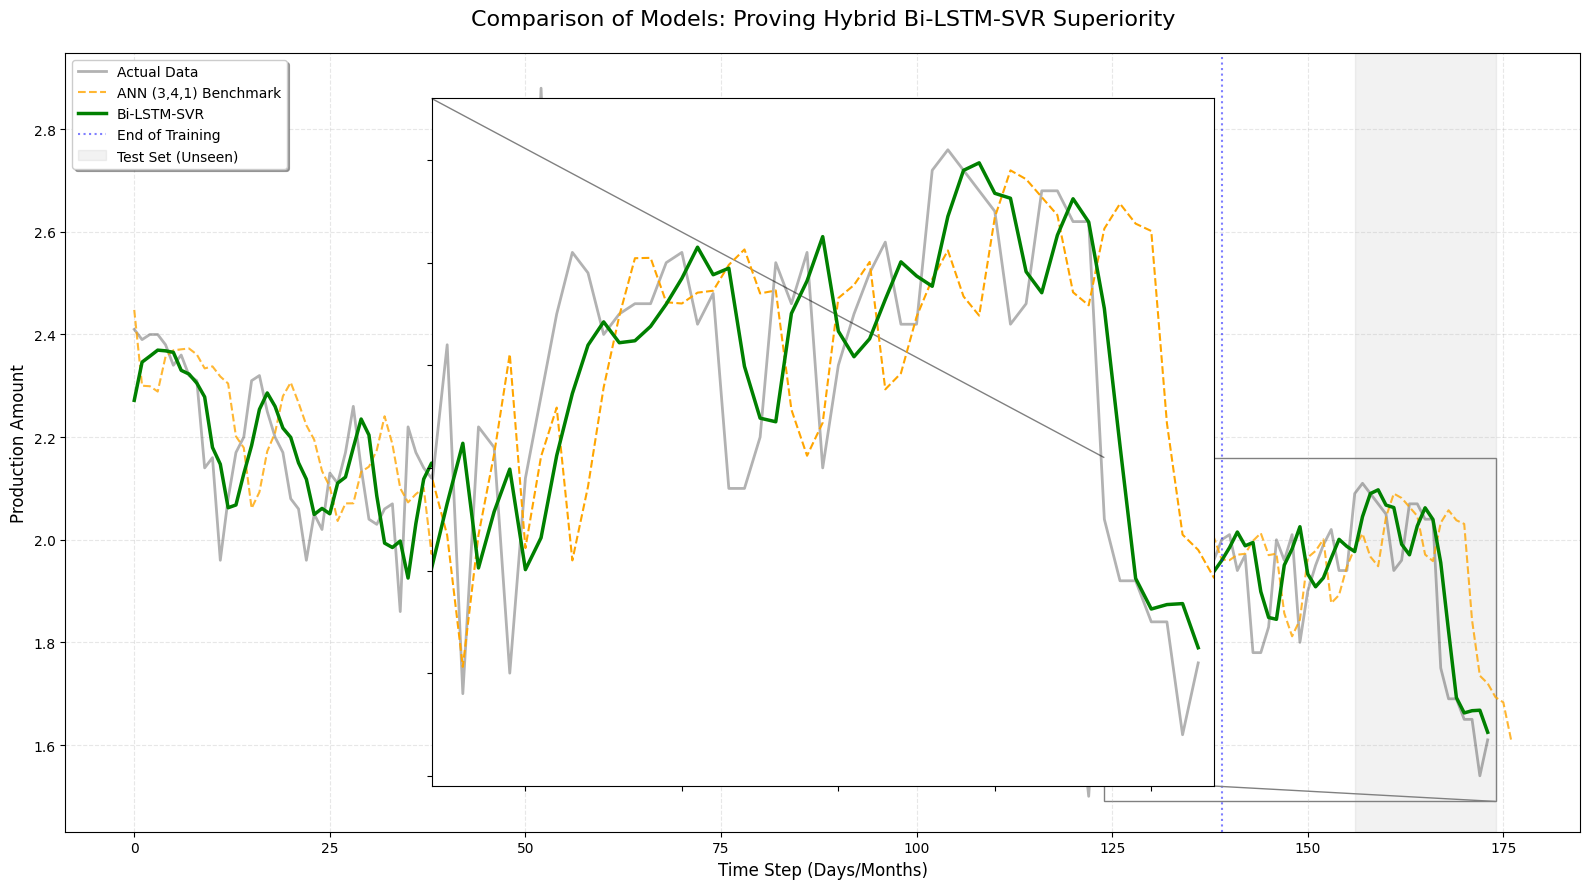

<Figure size 640x480 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt

# 1. Setup the figure
plt.figure(figsize=(16, 9))
plt.style.use('default') # Clean white background for papers

# 2. Plot the Entire Timeline
# Actual Data (Ground Truth)
plt.plot(full_actual, label='Actual Data', color='black', alpha=0.3, linewidth=2)

# The Other Paper's Model
plt.plot(ann_bench_predictions, label='ANN (3,4,1) Benchmark',
         color='orange', linestyle='--', linewidth=1.5, alpha=0.8)

# YOUR Superior Model (Hybrid)
plt.plot(full_hybrid, label='Bi-LSTM-SVR',
         color='green', linewidth=2.5, alpha=1.0)

# 3. Add Vertical Markers for Splitting
plt.axvline(x=train_split_idx, color='blue', linestyle=':', alpha=0.5, label='End of Training')
plt.axvspan(val_split_idx, len(full_actual), color='gray', alpha=0.1, label='Test Set (Unseen)')

# 4. Formatting
plt.title('Comparison of Models: Proving Hybrid Bi-LSTM-SVR Superiority', fontsize=16, pad=20)
plt.xlabel('Time Step (Days/Months)', fontsize=12)
plt.ylabel('Production Amount', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.3)

# 5. ZOOM INSET: To show the "Hugging" clearly
# We create an inset plot focusing on the last 50 points of the Test Set
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

ax = plt.gca()
axins = zoomed_inset_axes(ax, zoom=2, loc='center') # zoom=2 means 2x magnification

# Plot the same data on the zoomed axis
axins.plot(full_actual, color='black', alpha=0.3, linewidth=2)
axins.plot(ann_bench_predictions, color='orange', linestyle='--', linewidth=1.5)
axins.plot(full_hybrid, color='green', linewidth=2.5)

# Set the limits for the zoom (Focusing on the end of the Test Set)
x1, x2 = len(full_actual) - 50, len(full_actual)
y1, y2 = np.min(full_actual[x1:x2]) - 0.05, np.max(full_actual[x1:x2]) + 0.05
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

plt.xticks(visible=False)
plt.yticks(visible=False)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.show()
plt.savefig('full_dataset_ANN ZOOM.png', dpi=300)

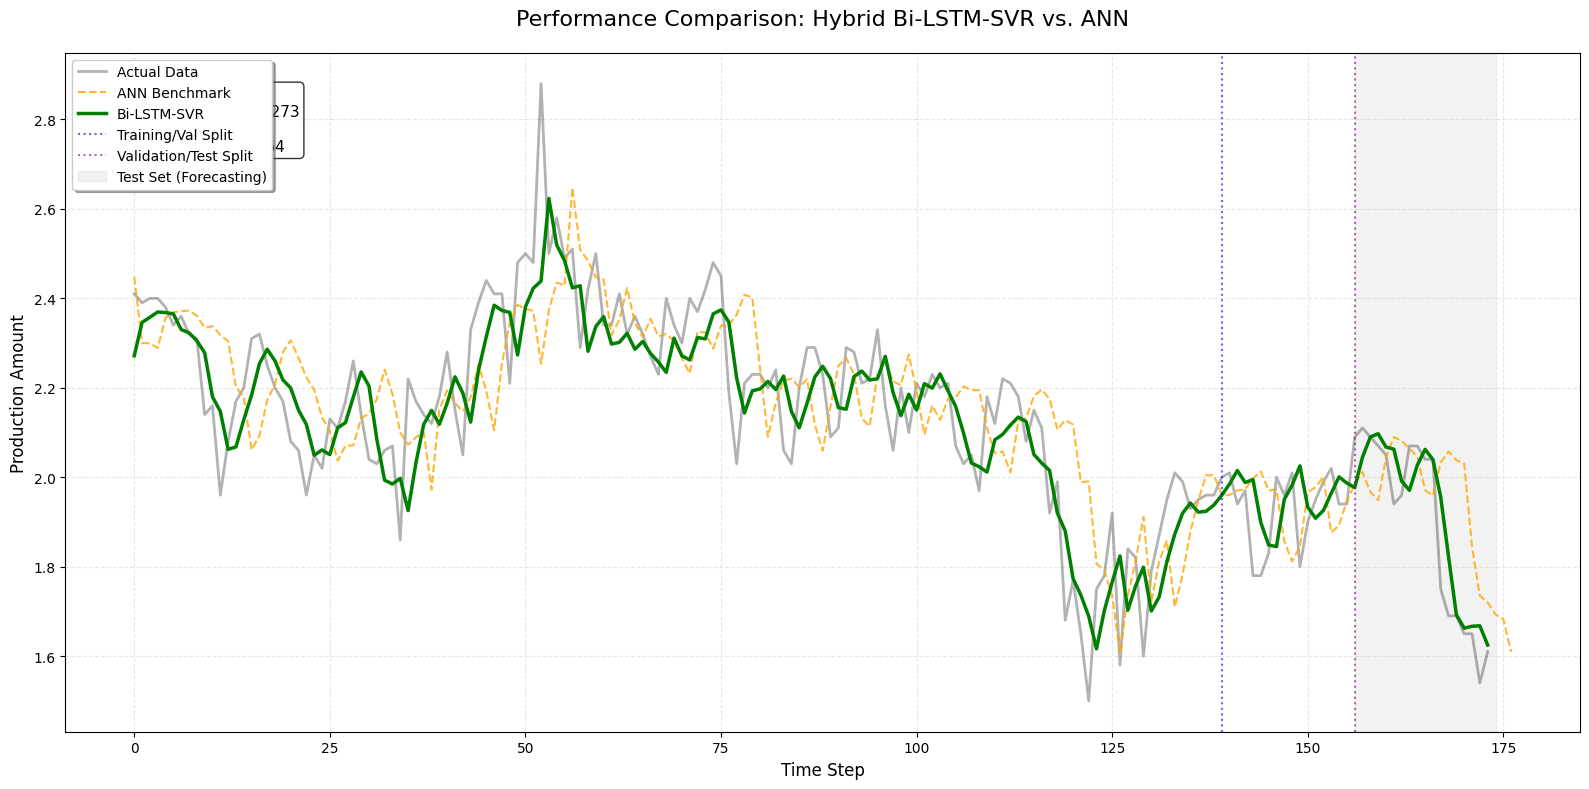

<Figure size 640x480 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt

# 1. Setup the figure
plt.figure(figsize=(16, 8))
plt.style.use('default') # Professional white background

# 2. Plot the Entire Timeline
# Actual Data (Ground Truth)
plt.plot(full_actual, label='Actual Data', color='black', alpha=0.3, linewidth=2)

# The Other Paper's Model (Benchmark)
plt.plot(ann_bench_predictions, label='ANN Benchmark',
         color='orange', linestyle='--', linewidth=1.5, alpha=0.8)

#Superior Model (Hybrid)
plt.plot(full_hybrid, label='Bi-LSTM-SVR',
         color='green', linewidth=2.5, alpha=1.0)

# 3. Add Visual Markers for Splitting
# Vertical line for Training end
plt.axvline(x=train_split_idx, color='blue', linestyle=':', alpha=0.6, label='Training/Val Split')
# Vertical line for Validation end
plt.axvline(x=val_split_idx, color='purple', linestyle=':', alpha=0.6, label='Validation/Test Split')

# Highlight the Test Zone (Unseen data)
plt.axvspan(val_split_idx, len(full_actual), color='gray', alpha=0.1, label='Test Set (Forecasting)')

# 4. Formatting and Labels
plt.title('Performance Comparison: Hybrid Bi-LSTM-SVR vs. ANN', fontsize=16, pad=20)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Production Amount', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)

# 5. Add a text box for final Test Metrics comparison
test_nse_hybrid = test_metrics['NSE']
# Calculate benchmark NSE on the test slice
test_actual_slice = full_actual[val_split_idx:]
test_ann_slice = ann_bench_predictions[val_split_idx:]
test_nse_ann = 1 - (np.sum((test_actual_slice - test_ann_slice)**2) / np.sum((test_actual_slice - np.mean(test_actual_slice))**2))

stats_text = (f"Test NSE Results:\n"
              f"ANN Benchmark: {test_nse_ann:.4f}\n"
              f"Your Hybrid: {test_nse_hybrid:.4f}\n"
              f"Improvement: +{test_nse_hybrid - test_nse_ann:.4f}")

plt.gca().text(0.02, 0.95, stats_text, transform=plt.gca().transAxes,
               fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('final_superiority_plot.png', dpi=300)
plt.show()
plt.savefig('full_dataset_ANN.png', dpi=300)

In [ ]:
import joblib # For SVR and Scalers
import pickle

# 1. Save the Bi-LSTM Model
bilstm_model.save('bilstm_model.h5')

# 2. Save the SVR Model
joblib.dump(best_svr, 'svr_residual_model.pkl')

# 3. Save the Scalers (CRITICAL: Deployment fails without these)
joblib.dump(scaler_features, 'feature_scaler.pkl')
joblib.dump(scaler_target, 'target_scaler.pkl')

print("All hybrid components saved successfully!")

All hybrid components saved successfully!


In [ ]:
import tensorflow as tf
import joblib
import numpy as np

class HybridModelDeployer:
    def __init__(self):
        # Load all components
        self.bilstm = tf.keras.models.load_model('bilstm_model.h5')
        self.svr = joblib.load('svr_residual_model.pkl')
        self.feat_scaler = joblib.load('feature_scaler.pkl')
        self.target_scaler = joblib.load('target_scaler.pkl')

    def predict(self, raw_input_sequence):
        # 1. Scale Input
        scaled_input = self.feat_scaler.transform(raw_input_sequence)
        scaled_input = scaled_input.reshape(1, scaled_input.shape[0], scaled_input.shape[1])

        # 2. Bi-LSTM Stage
        b_pred = self.bilstm.predict(scaled_input, verbose=0)

        # 3. SVR Stage
        # Combine last timestep of input + Bi-LSTM prediction
        svr_in = np.hstack([scaled_input[0, -1, :], b_pred[0]])
        correction = self.svr.predict(svr_in.reshape(1, -1))

        # 4. Final Hybrid & Inverse Scale
        final_scaled = b_pred + correction
        return self.target_scaler.inverse_transform(final_scaled)

# Usage
# model = HybridModelDeployer()
# print(model.predict(new_data))

In [ ]:
import joblib
# Save Neural Network
bilstm_model.save('bilstm_final.h5')
# Save SVR & Scalers
joblib.dump(best_svr, 'bilstm_svr_corrector.pkl')
joblib.dump(scaler_target, 'bilstm_target_scaler.pkl')
joblib.dump(scaler_features, 'bilstm_feat_scaler.pkl')

['bilstm_feat_scaler.pkl']